In [87]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os

data_folder = "./results"
 
def get_csvs_recursive(dir_name):
    """
    recursively finds all .csv files below a specified directory and returns them as 
    a list of file paths. Usefull for combining results from multiple simulation runs.
    """
    dir_list = os.listdir(dir_name)
    cur_fnames = []
    
    for item_name in dir_list:
        # if file
        if ".csv" in item_name:
            cur_fnames += [dir_name+"/"+item_name]
        # if folder
        elif "." not in item_name:
            sub_fnames = get_csvs_recursive(dir_name+"/"+item_name)
            cur_fnames += sub_fnames
    return cur_fnames
            
    
data_fnames = get_csvs_recursive(data_folder)

# combine all files into a longform dataframe for plotting
sim_dfs= []
for filename in data_fnames:
    cur_df = pd.read_csv(filename)
    sim_dfs += [cur_df]
        
phrase_df = pd.concat(sim_dfs).reset_index(drop=True)
phrase_df

,Target Phrase,Phrase Type,Typed Text,Click Load (clicks/character),Click Load (clicks/selection),Entry Rate (cpm),Entry Rate (wpm),Correction Rate (%),Error Rate (%),Word Prediction Usage (%),Session Num,Trial Num,Phrase Num,user_id
0,i'm so late to answer this ..,?,i'm so late to answer this..,1.310,3.800,14.612,2.922,0.000,0.000,60.000,1,0,1,A
1,try to learn something today ..,?,try to learn something today..,0.903,2.800,6.330,1.266,0.000,0.000,50.000,1,0,2,A
2,another little dog named bourre ..,?,another little dog named bourre..,1.618,2.750,13.630,2.726,5.000,0.000,20.000,1,0,3,A
3,scam before you get scammed ..,?,scam before you get scammed..,1.100,2.357,20.322,4.064,0.000,0.000,28.571,2,0,1,A
4,thanks tricare for dropping the ball ..,?,thanks tricare for dropping the ball..,1.359,2.524,3.548,0.710,4.762,0.000,23.810,2,0,2,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,i do recommend your book ..,?,i do recommend your book..,1.074,2.900,11.716,2.343,0.000,0.000,50.000,2,0,3,G
477,woke up still loving y'all ..,?,awoke up still loving y'all..,1.600,2.824,8.663,1.733,5.882,3.704,29.412,3,0,1,G
478,conte's blue and white army ..,?,conte's blue and white army..,1.867,2.800,7.128,1.426,5.000,0.000,20.000,3,0,2,G
479,part of me is missing ..,?,apart of me is missing..,0.960,3.000,16.626,3.325,0.000,4.545,62.500,4,0,1,G


In [88]:
user_eval_sessions = {}
for row in phrase_df[["user_id", "Session Num"]].groupby("user_id").agg("max").iterrows():
    cur_user_id = row[0]
    cur_max_session = row[1].values[0]
    user_eval_sessions[cur_user_id] = [i for i in range(cur_max_session-2, cur_max_session+1) if i > 0]

user_eval_sessions

{'A': [5, 6, 7],
 'B': [15, 16, 17],
 'C': [5, 6, 7],
 'D': [1, 2, 3],
 'F': [1, 2],
 'G': [2, 3, 4]}

In [69]:
valid_sessions = np.vectorize(lambda x, y: y in user_eval_sessions[x])(plot_df["user_id"].values, plot_df["Session Num"].values)
plot_df = phrase_df.loc[valid_sessions, :]

plot_df[["user_id", "Session Num"]].drop_duplicates()

,user_id,Session Num
18,A,5
24,A,6
29,A,7
105,B,15
107,B,16
110,B,17
125,C,6
127,C,7
130,C,8
132,D,1


In [18]:
# load all the real user data as one longform dataframe for plotting
real_dfs = []
for user_id in phrase_df.user_id.unique():
    real_data_fname = "../../../Nomon_User_Data/OSF Data/text_entry_task/user_"+user_id+"_text_phrase_data_clean.csv"
    cur_df = pd.read_csv(real_data_fname)[
        ["Session Num", "Phrase Num", "Phrase Text", "Typed Text", "Click Load (clicks/character)", "Entry Rate (wpm)", "Correction Rate (% of selections)", "Final Error Rate (%)"]]
    cur_df["user_id"] = user_id
    real_dfs.append(cur_df)
    
real_df = pd.concat(real_dfs).reset_index(drop=True)
# rename columns to match between real and sim dfs
real_df = real_df.rename(columns={"Phrase Text": "Target Phrase", "Correction Rate (% of selections)": "Correction Rate (%)", "Final Error Rate (%)": "Error Rate (%)"})
real_df.head()


,Session Num,Phrase Num,Target Phrase,Typed Text,Click Load (clicks/character),Entry Rate (wpm),Correction Rate (%),Error Rate (%),user_id
0,1.0,1.0,another little dog named bourre,another little dog named bourre.,2.219,2.058,8.696,0.0,A
1,1.0,2.0,try to learn something today,try to learn something today.,1.345,3.824,0.000,0.0,A
2,1.0,3.0,i'm so late to answer this,i'm so late to answer this.,1.704,2.551,0.000,0.0,A
3,2.0,1.0,that was actually a question,that was actually a question.,1.310,3.324,0.000,0.0,A
4,2.0,2.0,this has given me the fear,this has given me the fear.,1.481,2.678,0.000,0.0,A


<AxesSubplot:xlabel='user_id', ylabel='Click Load (clicks/character)'>

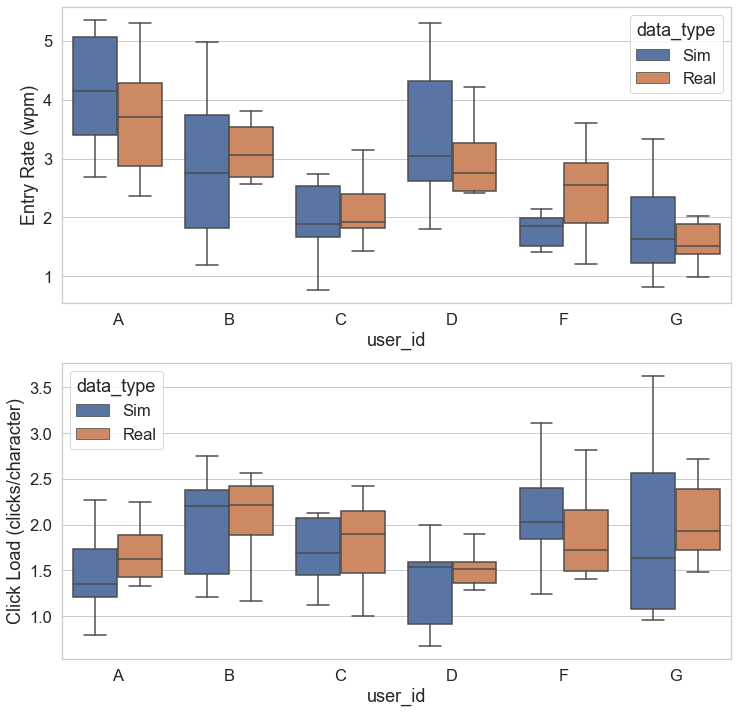

In [86]:
# setup and format a double figure for the plots
fig, axes = plt.subplots(2,1, figsize=(12, 12))
sns.set_context("paper")
sns.set(font_scale=1.5)
sns.set_style("whitegrid")

# create a single longform df with real and sim results for the comparison plot
real_df_cols = real_df.columns.values.tolist()
phrase_df["data_type"] = "Sim"
sim_df = phrase_df
real_df["data_type"] = "Real"
plot_df = pd.concat([sim_df[real_df_cols], real_df])

valid_sessions = np.vectorize(lambda x, y: y in user_eval_sessions[x])(plot_df["user_id"].values, plot_df["Session Num"].values)
plot_df = plot_df.loc[valid_sessions, :]



# plot the data as boxplots
sns.boxplot(data=plot_df, x="user_id", y="Entry Rate (wpm)", hue="data_type", showfliers=False, ax=axes[0])
sns.boxplot(data=plot_df, x="user_id", y="Click Load (clicks/character)", hue="data_type", showfliers=False, ax=axes[1])
